Create an “Academic performance” dataset of students and perform the following operations using Python.
1. Scan all variables for missing values and inconsistencies. If there are missing values and/or
inconsistencies, use any of the suitable techniques to deal with them.
2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal with
them.
3. Apply data transformations on at least one of the variables. The purpose of this transformation should be one of the following reasons: to change the scale for better understanding of the variable, to convert a non-linear relation into a linear one, or to decrease the skewness and convert the distribution into a normal distribution.

In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

# Possible categorical values
genders = ["male", "female"]
race_groups = ["group A", "group B", "group C", "group D", "group E"]
parent_education = [
    "some high school", "high school", "some college",
    "associate's degree", "bachelor's degree", "master's degree"
]
lunch_types = ["standard", "free/reduced"]
test_prep = ["none", "completed"]

# Generate 20 records
n = 20

data = {
    "gender": np.random.choice(genders, n),
    "race/ethnicity": np.random.choice(race_groups, n),
    "parental level of education": np.random.choice(parent_education, n),
    "lunch": np.random.choice(lunch_types, n),
    "test preparation course": np.random.choice(test_prep, n),
    "math score": np.random.randint(40, 100, n).astype(float),
    "reading score": np.random.randint(40, 100, n).astype(float),
    "writing score": np.random.randint(40, 100, n).astype(float)
}

# Create DataFrame
df = pd.DataFrame(data)

# Introduce null values ONLY in numeric columns
numeric_cols = ["math score", "reading score", "writing score"]

for col in numeric_cols:
    df.loc[df.sample(frac=0.1).index, col] = np.nan

# Display dataset
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,79.0,46.0,67.0
1,female,group B,some high school,free/reduced,none,60.0,48.0,46.0
2,male,group D,some college,standard,none,55.0,63.0,48.0
3,male,group B,bachelor's degree,free/reduced,completed,84.0,40.0,47.0
4,male,group D,some college,standard,completed,57.0,83.0,NaN
5,female,group E,bachelor's degree,free/reduced,completed,86.0,47.0,73.0
6,male,group A,some high school,standard,completed,92.0,63.0,72.0
7,male,group D,high school,standard,completed,63.0,50.0,87.0
8,male,group B,associate's degree,free/reduced,completed,65.0,90.0,94.0
9,female,group E,some high school,standard,completed,64.0,56.0,NaN


In [3]:
print("\nDataset Info:\n")
#Displaying the dataset information
df.describe()


Dataset Info:



,math score,reading score,writing score
count,18.000000,18.000000,18.000000
mean,75.111111,65.500000,68.000000
std,15.840710,19.321582,14.919391
min,54.000000,40.000000,40.000000
25%,63.250000,47.250000,61.500000
50%,73.500000,63.000000,72.500000
75%,85.500000,80.750000,75.500000
max,99.000000,98.000000,94.000000


In [4]:
print("shape and size of the data: ", df.shape, df.size)

shape and size of the data:  (20, 8) 160


In [5]:
#Checking for missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     2
reading score                  2
writing score                  2
dtype: int64


In [6]:
#Filling missing values with mean for numerical columns
for i in ["reading score", "writing score","math score"]:
    df[i] = df[i].fillna(df[i].mean())
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,79.0,46.0,67.0
1,female,group B,some high school,free/reduced,none,60.0,48.0,46.0
2,male,group D,some college,standard,none,55.0,63.0,48.0
3,male,group B,bachelor's degree,free/reduced,completed,84.0,40.0,47.0
4,male,group D,some college,standard,completed,57.0,83.0,68.0


In [8]:
# Introduce outliers
df.loc[0, "math score"] = 180
df.loc[1, "math score"] = 5
df.loc[2, "reading score"] = 170
df.loc[3, "reading score"] = 10
df.loc[4, "writing score"] = 200
df.loc[5, "writing score"] = 15

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,180.0,46.0,67.0
1,female,group B,some high school,free/reduced,none,5.0,48.0,46.0
2,male,group D,some college,standard,none,55.0,170.0,48.0
3,male,group B,bachelor's degree,free/reduced,completed,84.0,10.0,47.0
4,male,group D,some college,standard,completed,57.0,83.0,200.0


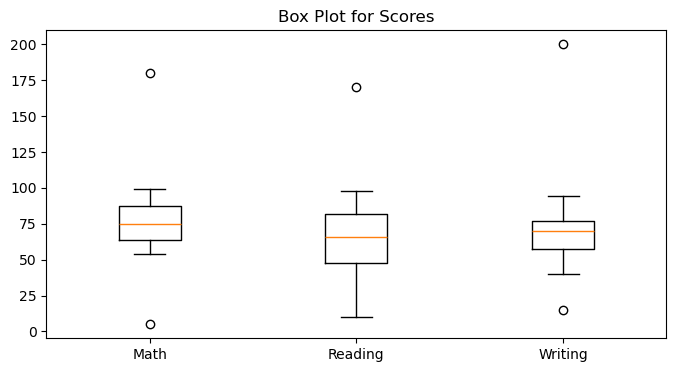

In [9]:
# Boxplots
plt.figure(figsize=(8, 4))
plt.boxplot(df[["math score","reading score","writing score"]],tick_labels=["Math", "Reading", "Writing"])
plt.title("Box Plot for Scores")
plt.show()

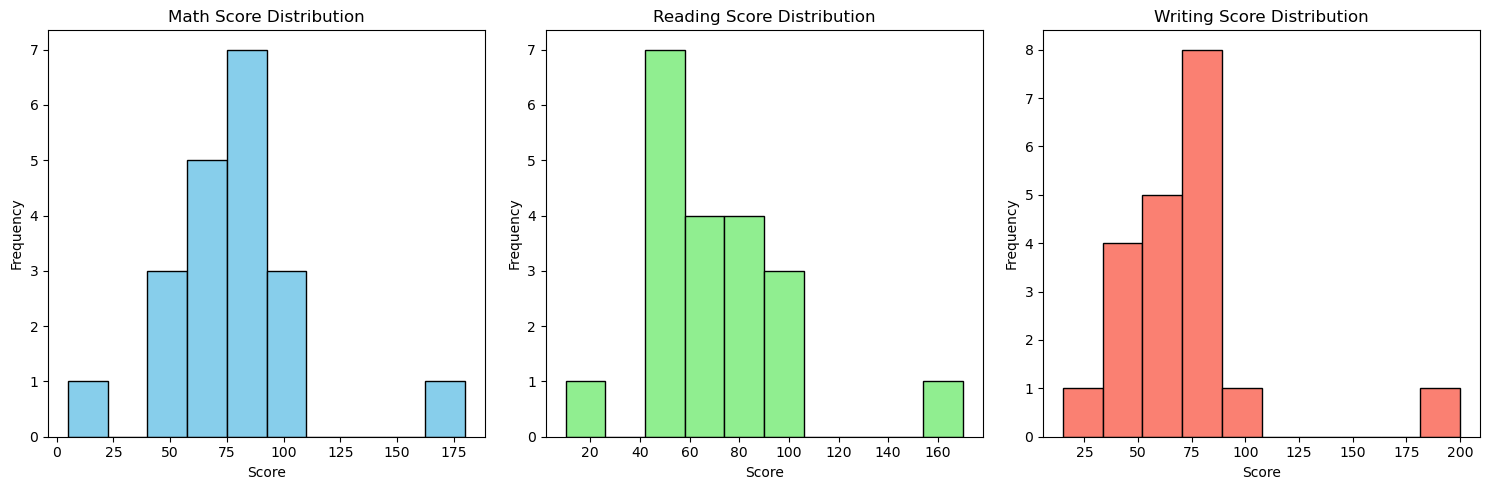

In [10]:
# Histogram for Math, Reading, and Writing scores in a 1x3 grid
plt.figure(figsize=(15, 5))

# Math Score Distribution
plt.subplot(1, 3, 1)
plt.hist(df["math score"], bins=10, color='skyblue', edgecolor='black')
plt.title("Math Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

# Reading Score Distribution
plt.subplot(1, 3, 2)
plt.hist(df["reading score"], bins=10, color='lightgreen', edgecolor='black')
plt.title("Reading Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

# Writing Score Distribution
plt.subplot(1, 3, 3)
plt.hist(df["writing score"], bins=10, color='salmon', edgecolor='black')
plt.title("Writing Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

In [11]:
# Outlier detection (IQR)
Q1_math = df["math score"].quantile(0.25)
Q3_math = df["math score"].quantile(0.75)
IQR_math = Q3_math - Q1_math
lower_math = Q1_math - 1.5 * IQR_math
upper_math = Q3_math + 1.5 * IQR_math
math_outliers = df[(df["math score"] < lower_math) | (df["math score"] > upper_math)]

Q1_reading = df["reading score"].quantile(0.25)
Q3_reading = df["reading score"].quantile(0.75)
IQR_reading = Q3_reading - Q1_reading
lower_reading = Q1_reading - 1.5 * IQR_reading
upper_reading = Q3_reading + 1.5 * IQR_reading
reading_outliers = df[(df["reading score"] < lower_reading) | (df["reading score"] > upper_reading)]

Q1_writing = df["writing score"].quantile(0.25)
Q3_writing = df["writing score"].quantile(0.75)
IQR_writing = Q3_writing - Q1_writing
lower_writing = Q1_writing - 1.5 * IQR_writing
upper_writing = Q3_writing + 1.5 * IQR_writing
writing_outliers = df[(df["writing score"] < lower_writing) | (df["writing score"] > upper_writing)]

# Combine all three outlier DataFrames into one
all_outliers = pd.concat([math_outliers, reading_outliers, writing_outliers])
all_outliers = all_outliers.drop_duplicates()
all_outliers = all_outliers.reset_index(drop=True)
all_outliers

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group E,associate's degree,standard,completed,180.0,46.0,67.0
1,female,group B,some high school,free/reduced,none,5.0,48.0,46.0
2,male,group D,some college,standard,none,55.0,170.0,48.0
3,male,group D,some college,standard,completed,57.0,83.0,200.0
4,female,group E,bachelor's degree,free/reduced,completed,86.0,47.0,15.0


In [12]:
# Remove outliers
df_clean = df[
    (df["math score"] >= lower_math) & (df["math score"] <= upper_math) &
    (df["reading score"] >= lower_reading) & (df["reading score"] <= upper_reading) &
    (df["writing score"] >= lower_writing) & (df["writing score"] <= upper_writing)
].copy()

# Reset index so the new dataframe doesn't have gaps
df_clean = df_clean.reset_index(drop=True)

print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")

Original rows: 20
Cleaned rows: 15


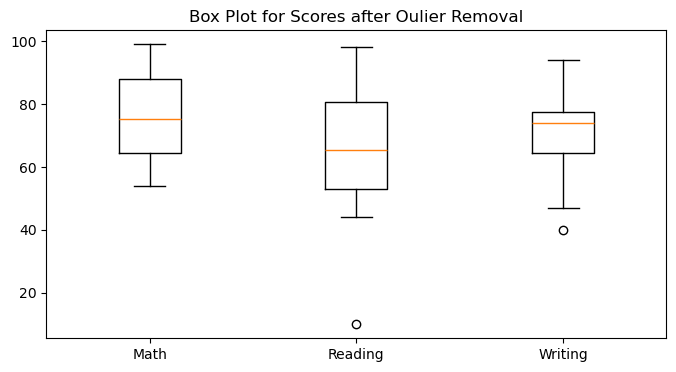

In [13]:
# Boxplots after cleaning
plt.figure(figsize=(8, 4))
plt.boxplot(df_clean[["math score","reading score","writing score"]],tick_labels=["Math", "Reading", "Writing"])
plt.title("Box Plot for Scores after Oulier Removal")
plt.show()

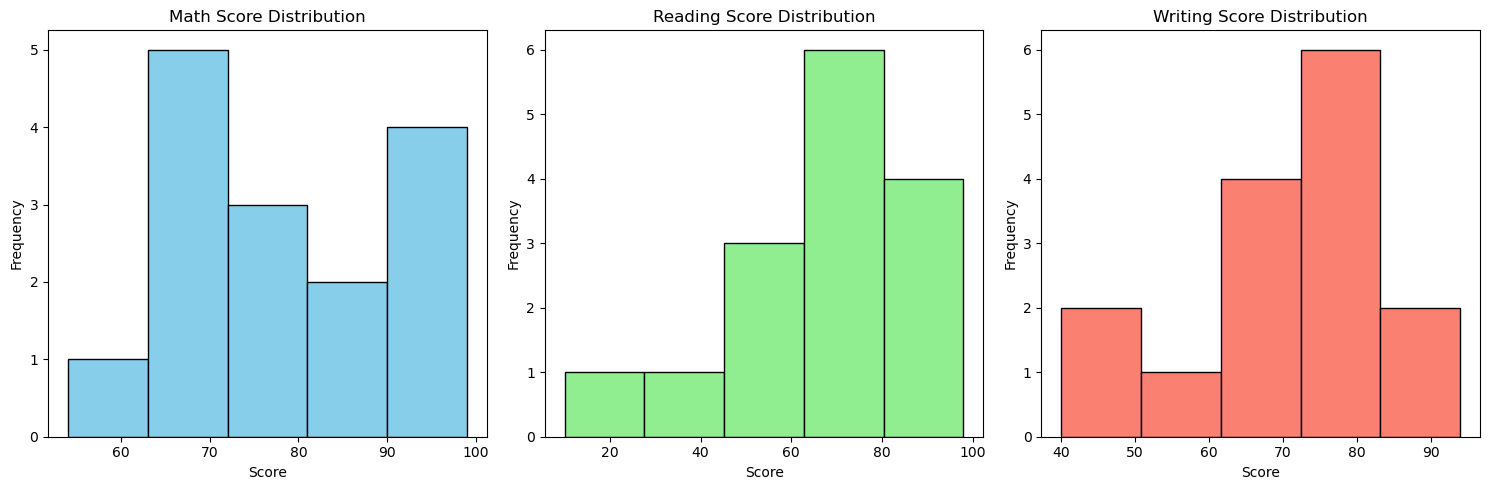

In [14]:
# Histogram for Math, Reading, and Writing scores after oulier removal
plt.figure(figsize=(15, 5))

# Math Score Distribution
plt.subplot(1, 3, 1)
plt.hist(df_clean["math score"], bins=5, color='skyblue', edgecolor='black')
plt.title("Math Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

# Reading Score Distribution
plt.subplot(1, 3, 2)
plt.hist(df_clean["reading score"], bins=5, color='lightgreen', edgecolor='black')
plt.title("Reading Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

# Writing Score Distribution
plt.subplot(1, 3, 3)
plt.hist(df_clean["writing score"], bins=5, color='salmon', edgecolor='black')
plt.title("Writing Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.tight_layout() # Adjusts spacing to prevent overlap
plt.show()

In [15]:
#Calculating Q1, Q3, IQR, lower limit, and upper limit for 'math score'
Q1 = df_clean['math score'].quantile(0.25)
Q3 = df_clean['math score'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)


Q1: 64.5
Q3: 88.0
IQR: 23.5
Lower Limit: 29.25
Upper Limit: 123.25


In [16]:
outliers = df_clean[(df_clean['math score'] < lower_limit) | (df_clean['math score'] > upper_limit)]
print("\nOutliers:\n", outliers)


Outliers:
 Empty DataFrame
Columns: [gender, race/ethnicity, parental level of education, lunch, test preparation course, math score, reading score, writing score]
Index: []


In [17]:
#Scaling the 'math score' column using Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_clean['math_scaled'] = scaler.fit_transform(df_clean[['math score']])


In [18]:
df_clean['math_zscore'] = (df_clean['math score'] - df_clean['math score'].mean()) / df_clean['math score'].std()


In [19]:
print("\nSkewness:\n", df_clean[['math score', 'reading score', 'writing score']].skew())


Skewness:
 math score       0.202093
reading score   -0.805718
writing score   -0.668795
dtype: float64


In [20]:
df_clean['math_log'] = np.log(df_clean['math score'])


In [21]:
print("\nStatistical Summary:\n")
df_clean.describe()


Statistical Summary:



,math score,reading score,writing score,math_scaled,math_zscore,math_log
count,15.000000,15.000000,15.000000,15.000000,1.500000e+01,15.000000
mean,77.681481,66.200000,70.533333,0.526255,-1.332268e-16,4.335502
std,14.813530,23.033981,14.085792,0.329190,1.000000e+00,0.192107
min,54.000000,10.000000,40.000000,0.000000,-1.598639e+00,3.988984
25%,64.500000,53.000000,64.500000,0.233333,-8.898271e-01,4.166635
50%,75.111111,65.500000,74.000000,0.469136,-1.735150e-01,4.318968
75%,88.000000,80.500000,77.500000,0.755556,6.965604e-01,4.476303
max,99.000000,98.000000,94.000000,1.000000,1.439125e+00,4.595120


In [22]:
df_clean

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,math_scaled,math_zscore,math_log
0,male,group B,bachelor's degree,free/reduced,completed,84.000000,10.0,47.0,0.666667,0.426537,4.430817
1,male,group A,some high school,standard,completed,92.000000,63.0,72.0,0.844444,0.966584,4.521789
2,male,group D,high school,standard,completed,63.000000,50.0,87.0,0.200000,-0.991086,4.143135
3,male,group B,associate's degree,free/reduced,completed,65.000000,90.0,94.0,0.244444,-0.856074,4.174387
4,female,group E,some high school,standard,completed,64.000000,56.0,68.0,0.222222,-0.923580,4.158883
5,male,group D,associate's degree,free/reduced,completed,99.000000,47.0,63.0,1.000000,1.439125,4.595120
6,male,group A,master's degree,free/reduced,none,99.000000,65.5,76.0,1.000000,1.439125,4.595120
7,male,group A,high school,free/reduced,completed,99.000000,74.0,74.0,1.000000,1.439125,4.595120
8,male,group C,high school,free/reduced,none,84.000000,72.0,83.0,0.666667,0.426537,4.430817
9,female,group C,some high school,free/reduced,completed,80.000000,98.0,79.0,0.577778,0.156514,4.382027
